### Classify iris flowers based on dataset measurments
⬛ Groups: setosa, versicolor, virginica

In [8]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, learning_curve)
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error,
    roc_curve, auc, roc_auc_score, log_loss, cohen_kappa_score)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from sklearn.exceptions import ConvergenceWarning




In [9]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PALETTE = ["#4C72B0", "#DD8452", "#55A868"] 

In [10]:
iris = pd.read_csv('iris.csv', index_col='Id')
iris.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
iris.describe().T

,count,mean,std,min,25%,50%,75%,max
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


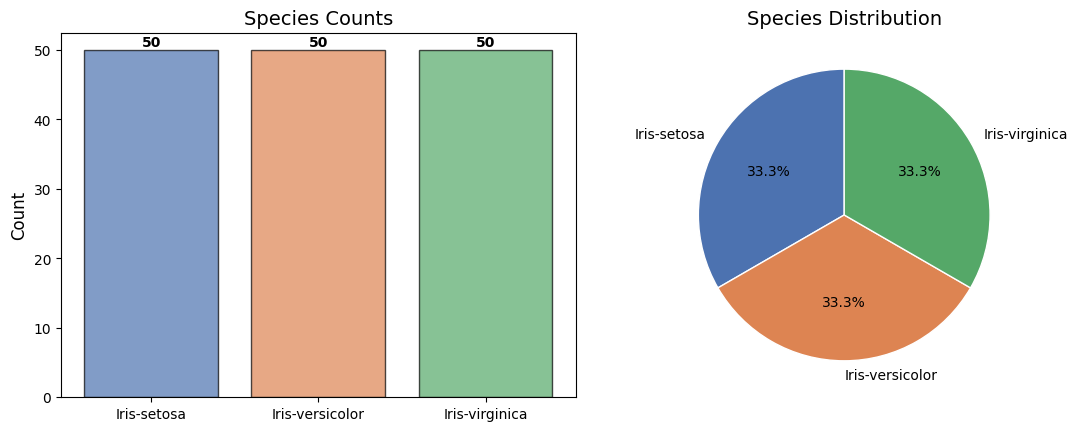

In [12]:
species_counts = iris['Species'].value_counts()

fid, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].bar(species_counts.index, species_counts.values, color=PALETTE[:len(species_counts)], edgecolor='black', alpha=0.7)
axes[0].set_title('Species Counts', fontsize=14)
axes[0].set_ylabel('Count', fontsize=12)
for i , v in enumerate(species_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight = "bold")

axes[1].pie(species_counts.values, labels=species_counts.index, autopct='%1.1f%%', colors=PALETTE[:len(species_counts)], startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1}, textprops={'fontsize': 10})
axes[1].set_title('Species Distribution', fontsize=14)

plt.show()

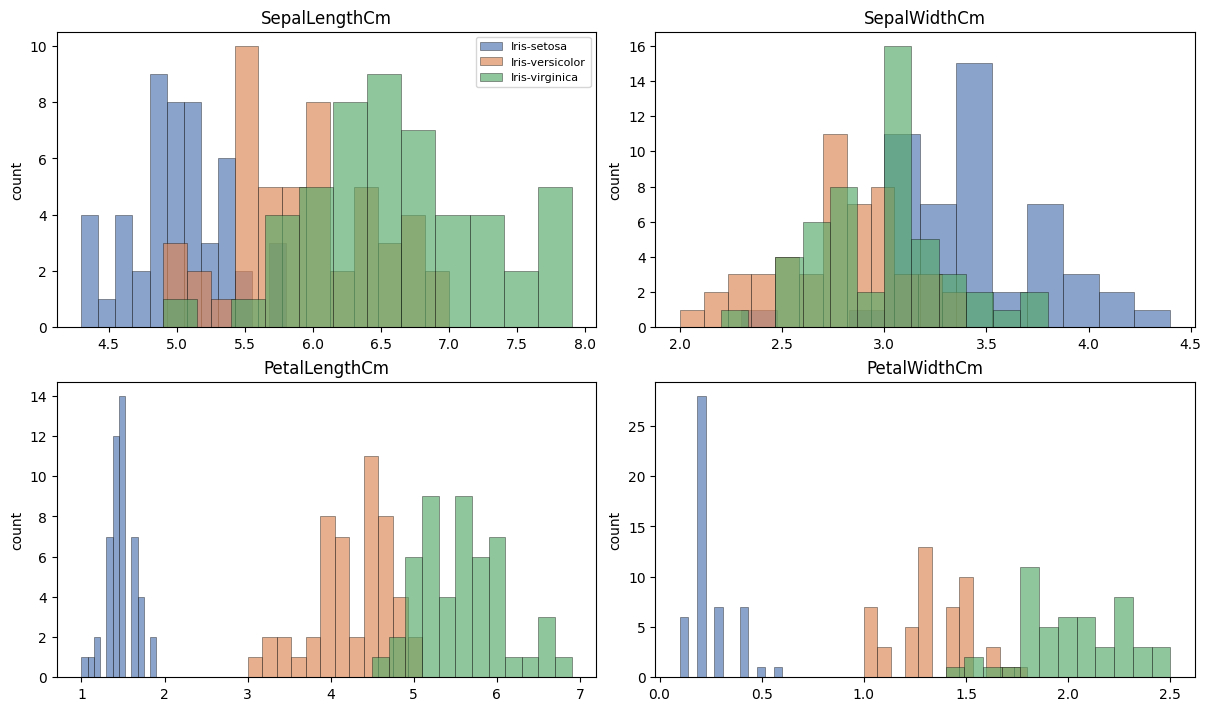

In [15]:
# EDA
features = [c for c in iris.columns if c != "Species"]
classes = sorted(iris["Species"].unique())

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for ax, feat in zip(axes.ravel(), features):
    for cls, color in zip(classes, PALETTE):
        ax.hist(iris.loc[iris["Species"] == cls, feat], bins=12, alpha=0.65,
                color=color, edgecolor="black", linewidth=0.4, label=cls)
    ax.set_title(feat)
    ax.set_ylabel("count")
axes[0, 0].legend(fontsize=8)
plt.show()

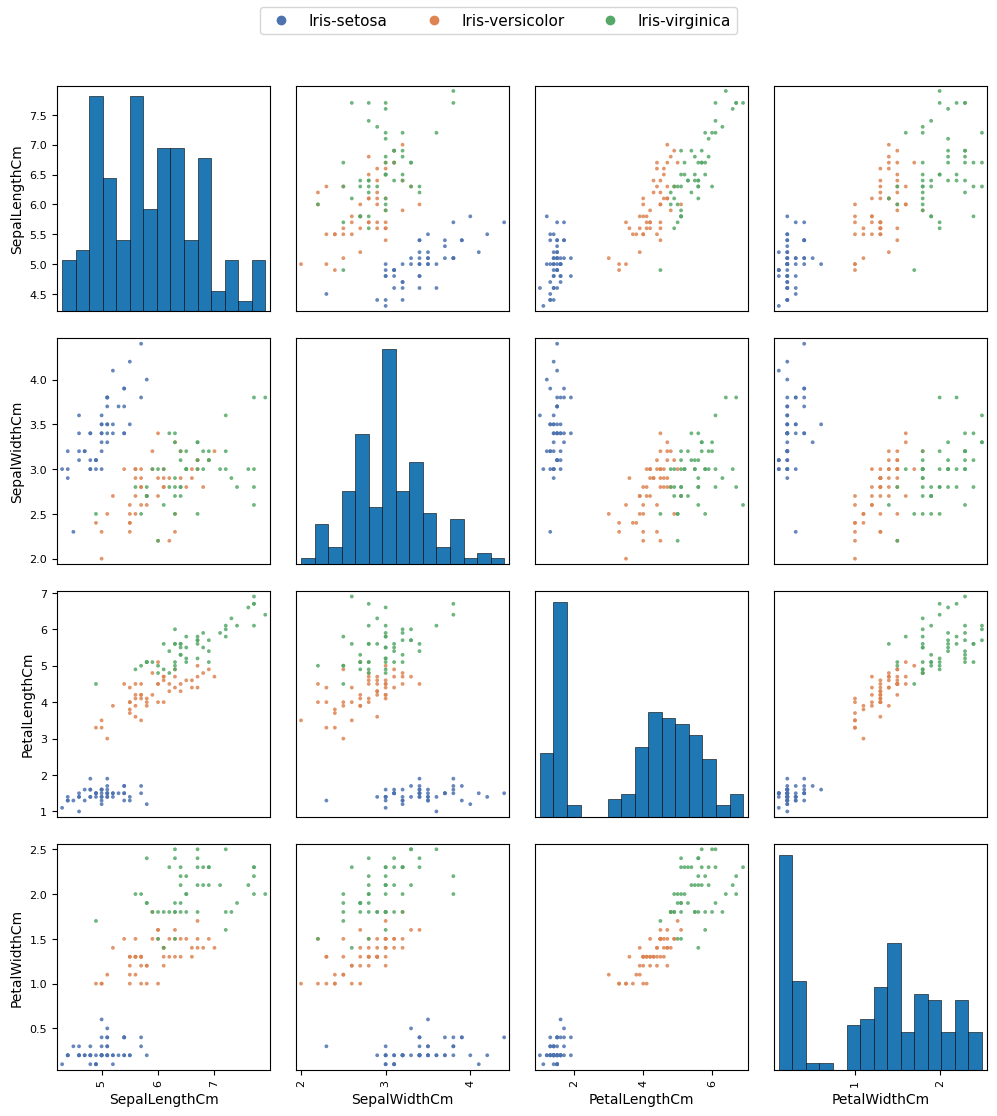

In [16]:
class_to_color = dict(zip(classes, PALETTE))
colors = iris["Species"].map(class_to_color)

pd.plotting.scatter_matrix(
    iris[features], figsize=(12, 12), c=colors, diagonal="hist",
    hist_kwds={"bins": 15, "edgecolor": "black", "linewidth": 0.4},
    s=30, alpha=0.85, edgecolors="none",
)

fig = plt.gcf()
fig.subplots_adjust(top=0.93, hspace=0.12, wspace=0.12)
handles = [Line2D([], [], marker="o", ls="", color=c, label=cl) for cl, c in class_to_color.items()]
fig.legend(handles=handles, loc="upper center", ncol=3, frameon=True, fontsize=11)
plt.show()

In [17]:
X = iris[features].copy()
y_raw = iris["Species"].copy()

label_encoder = LabelEncoder()
y = pd.Series(label_encoder.fit_transform(y_raw), name="SpeciesCode")
CLASS_NAMES = list(label_encoder.classes_)
print("Label encoding:", dict(zip(CLASS_NAMES, range(len(CLASS_NAMES)))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)

Label encoding: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


In [18]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_pipeline(estimator):
    "Impute -> scale -> model; fitted on training folds only at CV time (no leakage)."
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])

baseline = make_pipeline(KNeighborsClassifier())         
baseline_scores = cross_val_score(baseline, X_train, y_train, cv=CV, scoring="accuracy", n_jobs=-1)
print(f"Baseline KNN (defaults)  5-fold CV accuracy: {baseline_scores.mean():.4f} +/- {baseline_scores.std():.4f}")

Baseline KNN (defaults)  5-fold CV accuracy: 0.9583 +/- 0.0264


In [19]:
# Tuning 
k_values = range(1, 31)
weight_options = ["uniform", "distance"]
metric_options = {"Manhattan (p=1)": 1, "Euclidean (p=2)": 2}

knn_loop_rows = []
for w in weight_options:
    for metric_name, p in metric_options.items():
        for k in k_values:
            pipe = make_pipeline(KNeighborsClassifier(n_neighbors=k, weights=w, p=p))
            scores = cross_val_score(pipe, X_train, y_train, cv=CV, scoring="accuracy", n_jobs=-1)
            knn_loop_rows.append({
                "k": k, "weights": w, "metric": metric_name, "p": p,
                "cv_mean": scores.mean(), "cv_std": scores.std(),
            })

knn_loop_df = pd.DataFrame(knn_loop_rows)
best_knn_row = knn_loop_df.loc[knn_loop_df["cv_mean"].idxmax()]
print(f"Best manual-sweep configuration -> k = {best_knn_row['k']:.0f}, "
      f"weights = '{best_knn_row['weights']}', metric = {best_knn_row['metric']} "
      f"| CV accuracy = {best_knn_row['cv_mean']:.4f} +/- {best_knn_row['cv_std']:.4f}")

robust_zone = knn_loop_df[knn_loop_df["cv_mean"] >= best_knn_row["cv_mean"] - 0.01]
print(f"{len(robust_zone)} of {len(knn_loop_df)} configurations sit within 1% of the best score "
      f"(a wide plateau = robust operating region).")
knn_loop_df.head()

Best manual-sweep configuration -> k = 3, weights = 'uniform', metric = Euclidean (p=2) | CV accuracy = 0.9667 +/- 0.0167
48 of 120 configurations sit within 1% of the best score (a wide plateau = robust operating region).


,k,weights,metric,p,cv_mean,cv_std
0,1,uniform,Manhattan (p=1),1,0.933333,0.033333
1,2,uniform,Manhattan (p=1),1,0.933333,0.033333
2,3,uniform,Manhattan (p=1),1,0.958333,0.026352
3,4,uniform,Manhattan (p=1),1,0.958333,0.026352
4,5,uniform,Manhattan (p=1),1,0.958333,0.026352


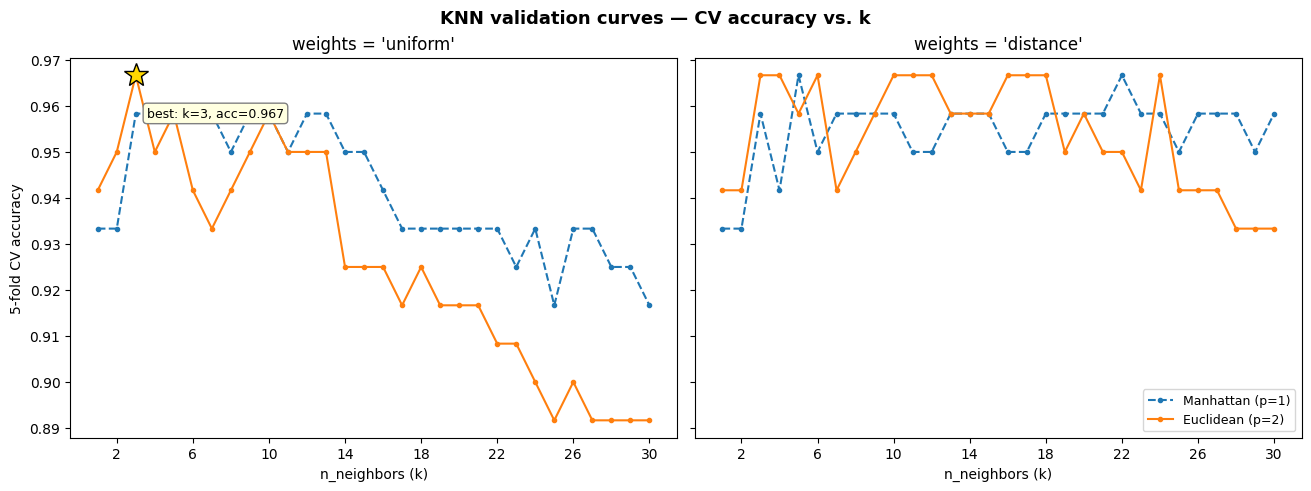

In [ ]:
line_styles = {"Manhattan (p=1)": "--", "Euclidean (p=2)": "-"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, constrained_layout=True)
for ax, w in zip(axes, weight_options):
    for metric_name in metric_options:
        grp = knn_loop_df[(knn_loop_df["weights"] == w) & (knn_loop_df["metric"] == metric_name)]
        ax.plot(grp["k"], grp["cv_mean"], line_styles[metric_name], marker="o",
                markersize=3, label=metric_name)
    ax.set_title(f"weights = '{w}'")
    ax.set_xlabel("n_neighbors (k)")
    ax.set_xticks(range(2, 31, 4))

axes[0].set_ylabel("5-fold CV accuracy")


ax_best = axes[0] if best_knn_row["weights"] == "uniform" else axes[1]
bx, by = best_knn_row["k"], best_knn_row["cv_mean"]
ax_best.plot(bx, by, marker="*", markersize=18, color="gold", markeredgecolor="black", zorder=5)
ax_best.annotate(f"best: k={bx:.0f}, acc={by:.3f}", (bx, by), textcoords="offset points",
                 xytext=(8, -30), fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))

axes[1].legend(loc="lower right", fontsize=9)
fig.suptitle("KNN validation curves — CV accuracy vs. k", fontsize=13, fontweight="bold")
plt.show()

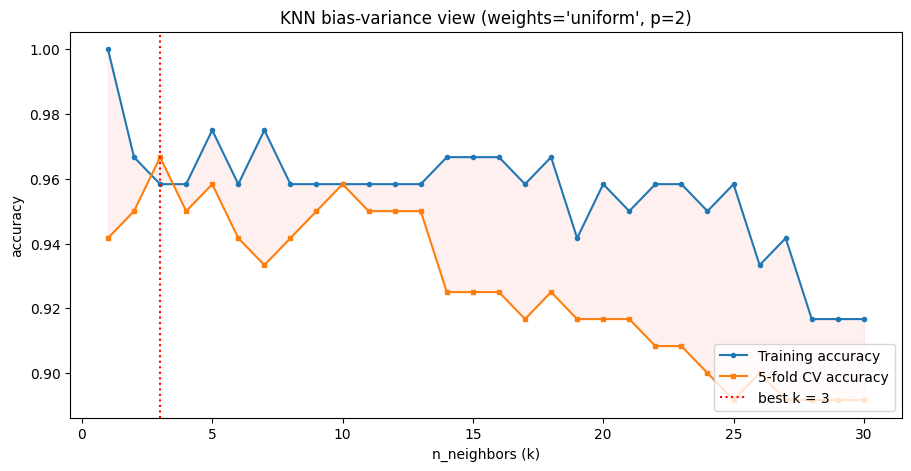

In [21]:
train_acc, cv_acc = [], []
for k in k_values:
    pipe = make_pipeline(KNeighborsClassifier(
        n_neighbors=k, weights=best_knn_row["weights"], p=best_knn_row["p"]))
    pipe.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, pipe.predict(X_train)))
    cv_acc.append(cross_val_score(pipe, X_train, y_train, cv=CV, scoring="accuracy", n_jobs=-1).mean())

train_acc = np.array(train_acc)
cv_acc = np.array(cv_acc)
best_k = int(k_values[int(cv_acc.argmax())])

fig, ax = plt.subplots(figsize=(9, 4.6), constrained_layout=True)
ax.plot(k_values, train_acc, "o-", markersize=3, label="Training accuracy")
ax.plot(k_values, cv_acc, "s-", markersize=3, label="5-fold CV accuracy")
ax.axvline(best_k, color="red", ls=":", lw=1.5, label=f"best k = {best_k}")
ax.fill_between(k_values, train_acc, cv_acc, color="red", alpha=0.06)
ax.set_xlabel("n_neighbors (k)")
ax.set_ylabel("accuracy")
ax.set_title(f"KNN bias-variance view (weights='{best_knn_row['weights']}', p={best_knn_row['p']})")
ax.legend(loc="lower right")
plt.show()


In [22]:
C_values = np.logspace(-3, 3, 13)              
penalty_solver = {"l1": "saga", "l2": "saga"}   

logreg_loop_rows = []
for penalty, solver in penalty_solver.items():
    for C in C_values:
        pipe = make_pipeline(LogisticRegression(
            C=C, penalty=penalty, solver=solver, max_iter=5000, random_state=RANDOM_STATE))
        scores = cross_val_score(pipe, X_train, y_train, cv=CV, scoring="accuracy", n_jobs=-1)
        logreg_loop_rows.append({"C": C, "penalty": penalty,
                                 "cv_mean": scores.mean(), "cv_std": scores.std()})

logreg_loop_df = pd.DataFrame(logreg_loop_rows)
best_logreg_row = logreg_loop_df.loc[logreg_loop_df["cv_mean"].idxmax()]

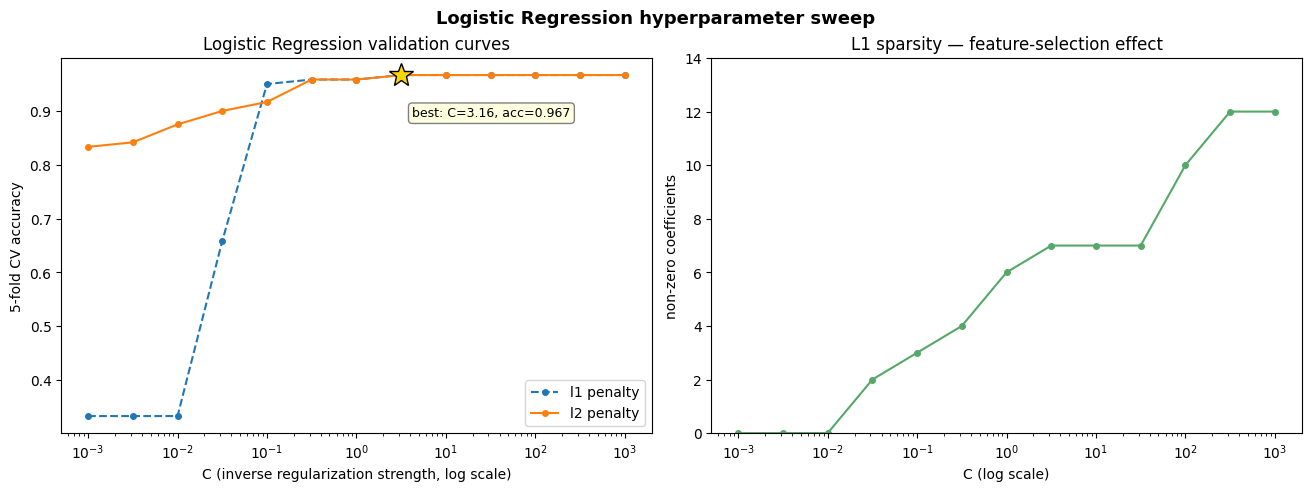

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

styles = {"l1": "--", "l2": "-"}
for penalty in ["l1", "l2"]:
    grp = logreg_loop_df[logreg_loop_df["penalty"] == penalty]
    axes[0].semilogx(grp["C"], grp["cv_mean"], styles[penalty], marker="o",
                     markersize=4, label=f"{penalty} penalty")
axes[0].set_xlabel("C (inverse regularization strength, log scale)")
axes[0].set_ylabel("5-fold CV accuracy")
axes[0].set_title("Logistic Regression validation curves")

bx, by = best_logreg_row["C"], best_logreg_row["cv_mean"]
axes[0].plot(bx, by, marker="*", markersize=18, color="gold", markeredgecolor="black", zorder=5)
axes[0].annotate(f"best: C={bx:.3g}, acc={by:.3f}", (bx, by), textcoords="offset points",
                 xytext=(8, -30), fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))
axes[0].legend(loc="lower right")

nonzero_counts = []
for C in C_values:
    pipe = make_pipeline(LogisticRegression(
        C=C, penalty="l1", solver="saga", max_iter=5000, random_state=RANDOM_STATE))
    pipe.fit(X_train, y_train)
    nonzero_counts.append(int(np.sum(pipe.named_steps["model"].coef_ != 0)))

axes[1].semilogx(C_values, nonzero_counts, "o-", color="#55A868", markersize=4)
axes[1].set_xlabel("C (log scale)")
axes[1].set_ylabel("non-zero coefficients")
axes[1].set_title("L1 sparsity — feature-selection effect")
axes[1].set_ylim(0, 14)

fig.suptitle("Logistic Regression hyperparameter sweep", fontsize=13, fontweight="bold")
plt.show()

In [24]:
knn_param_grid = {
    "model__n_neighbors": list(range(1, 31)),
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}

knn_grid = GridSearchCV(
    make_pipeline(KNeighborsClassifier()),
    knn_param_grid, cv=CV, scoring="accuracy", n_jobs=-1, return_train_score=True,
)
knn_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                                11, 12, 13, 14, 15, 16, 17, 18,
                                                19, 20, 21, 22, 23, 24, 25, 26,
                                                27, 28, 29, 30],
                         'model__p': [1, 2],
                         'model__weights': ['uniform', 'distance']},
             return_train_score=True, scoring='accuracy')

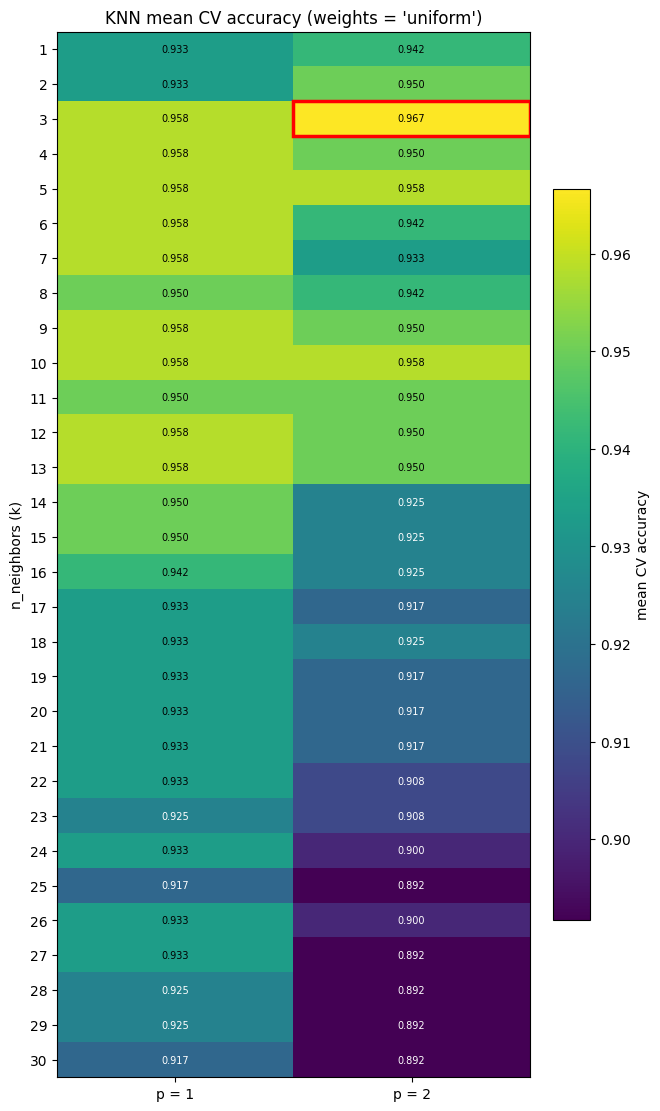

,k,weights,p,mean CV accuracy,std
0,3,uniform,2,0.966667,0.016667
1,3,distance,2,0.966667,0.016667
2,4,distance,2,0.966667,0.016667
3,5,distance,1,0.966667,0.016667
4,6,distance,2,0.966667,0.016667


In [25]:
knn_cv = pd.DataFrame(knn_grid.cv_results_)

weights_fixed = knn_grid.best_params_["model__weights"]
sub = knn_cv[knn_cv["param_model__weights"] == weights_fixed]
pivot = (sub.pivot_table(index="param_model__n_neighbors", columns="param_model__p",
                         values="mean_test_score").sort_index())

fig, ax = plt.subplots(figsize=(6.5, 11), constrained_layout=True)
im = ax.imshow(pivot.values.astype(float), cmap="viridis", aspect="auto")
ax.set_xticks(range(pivot.shape[1]), labels=[f"p = {c}" for c in pivot.columns])
ax.set_yticks(range(pivot.shape[0]), labels=pivot.index.astype(int))
ax.set_ylabel("n_neighbors (k)")
ax.set_title(f"KNN mean CV accuracy (weights = '{weights_fixed}')")

vmin, vmax = pivot.values.min(), pivot.values.max()
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        frac = (v - vmin) / (vmax - vmin)
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7,
                color="white" if frac < 0.55 else "black")

best_k = knn_grid.best_params_["model__n_neighbors"]
best_p = knn_grid.best_params_["model__p"]
bi = list(pivot.index).index(best_k)
bj = list(pivot.columns).index(best_p)
ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor="red", lw=2.5))
fig.colorbar(im, ax=ax, shrink=0.7, label="mean CV accuracy")
plt.show()

top5 = (knn_cv.nlargest(5, "mean_test_score")
        [["param_model__n_neighbors", "param_model__weights", "param_model__p",
          "mean_test_score", "std_test_score"]].reset_index(drop=True))
top5.columns = ["k", "weights", "p", "mean CV accuracy", "std"]
top5

In [26]:
logreg_param_grid = {
    "model__C": list(C_values),
    "model__penalty": ["l1", "l2"],
    "model__solver": ["saga"],
    "model__max_iter": [5000],
}

logreg_grid = GridSearchCV(
    make_pipeline(LogisticRegression(random_state=RANDOM_STATE)),
    logreg_param_grid, cv=CV, scoring="accuracy", n_jobs=-1,
)
logreg_grid.fit(X_train, y_train)

print(f"LogReg grid: {len(C_values) * 2} combinations x 5 folds")
print(f"Best LogReg params : {logreg_grid.best_params_}")
print(f"Best CV accuracy   : {logreg_grid.best_score_:.4f}")

LogReg grid: 26 combinations x 5 folds
Best LogReg params : {'model__C': 3.1622776601683795, 'model__max_iter': 5000, 'model__penalty': 'l1', 'model__solver': 'saga'}
Best CV accuracy   : 0.9667


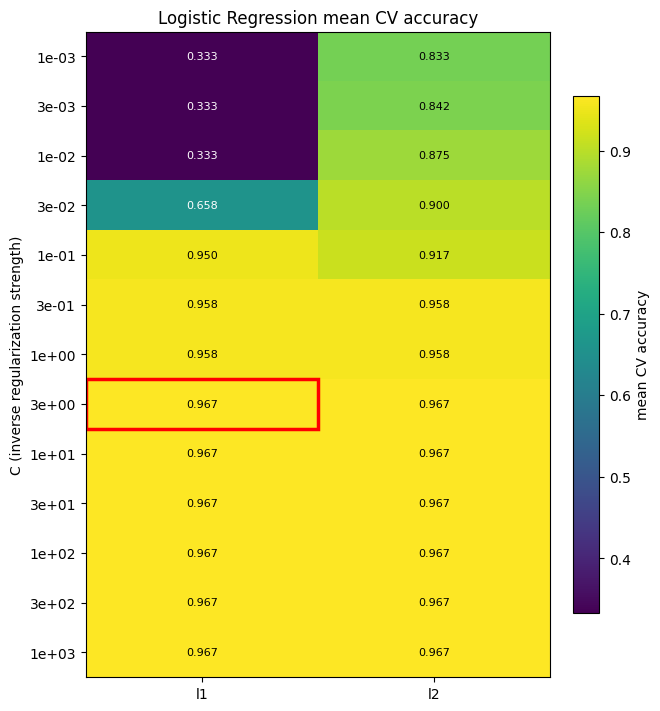

,C,penalty,mean CV accuracy,std
0,3.162278,l1,0.966667,0.03118
1,3.162278,l2,0.966667,0.03118
2,10.000000,l1,0.966667,0.03118
3,10.000000,l2,0.966667,0.03118
4,31.622777,l1,0.966667,0.03118


In [27]:
logreg_cv = pd.DataFrame(logreg_grid.cv_results_)
pivot_lr = (logreg_cv.pivot_table(index="param_model__C", columns="param_model__penalty",
                                  values="mean_test_score").sort_index())

fig, ax = plt.subplots(figsize=(6.5, 7), constrained_layout=True)
im = ax.imshow(pivot_lr.values.astype(float), cmap="viridis", aspect="auto")
ax.set_xticks(range(pivot_lr.shape[1]), labels=pivot_lr.columns)
ax.set_yticks(range(pivot_lr.shape[0]), labels=[f"{c:.0e}" for c in pivot_lr.index])
ax.set_ylabel("C (inverse regularization strength)")
ax.set_title("Logistic Regression mean CV accuracy")

vmin, vmax = pivot_lr.values.min(), pivot_lr.values.max()
for i in range(pivot_lr.shape[0]):
    for j in range(pivot_lr.shape[1]):
        v = pivot_lr.values[i, j]
        frac = (v - vmin) / (vmax - vmin)
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8,
                color="white" if frac < 0.55 else "black")

best_C = logreg_grid.best_params_["model__C"]
best_pen = logreg_grid.best_params_["model__penalty"]
bi = list(pivot_lr.index).index(best_C)
bj = list(pivot_lr.columns).index(best_pen)
ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor="red", lw=2.5))
fig.colorbar(im, ax=ax, shrink=0.8, label="mean CV accuracy")
plt.show()

top5_lr = (logreg_cv.nlargest(5, "mean_test_score")
           [["param_model__C", "param_model__penalty", "mean_test_score", "std_test_score"]]
           .reset_index(drop=True))
top5_lr.columns = ["C", "penalty", "mean CV accuracy", "std"]
top5_lr

In [28]:
models = {"KNN": knn_grid.best_estimator_,
          "Logistic Regression": logreg_grid.best_estimator_}
best_cv = {"KNN": knn_grid.best_score_,
           "Logistic Regression": logreg_grid.best_score_}

predictions, probabilities = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)                     # explicit refit (GridSearchCV already does this)
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)
    print(f"{name:<20s}  CV accuracy (5-fold, train): {best_cv[name]:.4f}   "
          f"|  test accuracy: {accuracy_score(y_test, predictions[name]):.4f}")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT - KNN")
print("=" * 70)
print(classification_report(y_test, predictions["KNN"], target_names=CLASS_NAMES, digits=4))

print("=" * 70)
print("CLASSIFICATION REPORT - LOGISTIC REGRESSION")
print("=" * 70)
print(classification_report(y_test, predictions["Logistic Regression"],
                            target_names=CLASS_NAMES, digits=4))

KNN                   CV accuracy (5-fold, train): 0.9667   |  test accuracy: 0.9333
Logistic Regression   CV accuracy (5-fold, train): 0.9667   |  test accuracy: 0.9667

CLASSIFICATION REPORT - KNN
                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000        10
Iris-versicolor     0.8333    1.0000    0.9091        10
 Iris-virginica     1.0000    0.8000    0.8889        10

       accuracy                         0.9333        30
      macro avg     0.9444    0.9333    0.9327        30
   weighted avg     0.9444    0.9333    0.9327        30

CLASSIFICATION REPORT - LOGISTIC REGRESSION
                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000        10
Iris-versicolor     1.0000    0.9000    0.9474        10
 Iris-virginica     0.9091    1.0000    0.9524        10

       accuracy                         0.9667        30
      macro avg     0.9697    0.9667    0.9666        30
   weighted

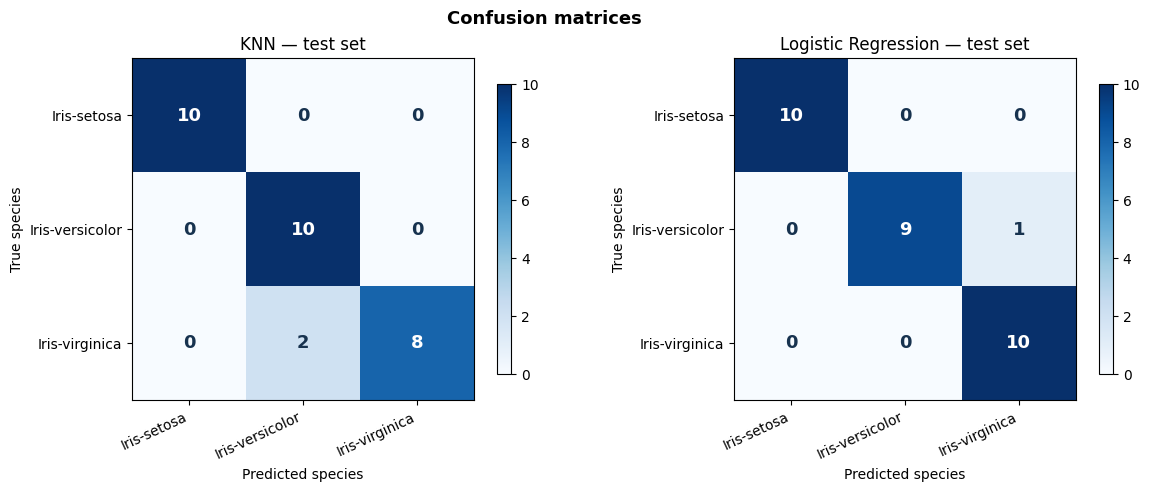

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    ax.set_xticks(range(len(CLASS_NAMES)), labels=CLASS_NAMES, rotation=25, ha="right")
    ax.set_yticks(range(len(CLASS_NAMES)), labels=CLASS_NAMES)
    ax.set_xlabel("Predicted species")
    ax.set_ylabel("True species")
    ax.set_title(f"{name} — test set")
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=13,
                    fontweight="bold", color="white" if cm[i, j] > thresh else "#17324f")
    fig.colorbar(im, ax=ax, shrink=0.85)
fig.suptitle("Confusion matrices", fontsize=13, fontweight="bold")
plt.show()

In [30]:
for name in models:
    mse = mean_squared_error(y_test, predictions[name])
    mae = mean_absolute_error(y_test, predictions[name])
    rmse = float(np.sqrt(mse))
    print(f"{name:<22s} MSE = {mse:.4f}   RMSE = {rmse:.4f}   MAE = {mae:.4f}")

KNN                    MSE = 0.0667   RMSE = 0.2582   MAE = 0.0667
Logistic Regression    MSE = 0.0333   RMSE = 0.1826   MAE = 0.0333


First two principal components explain 95.7% of the variance


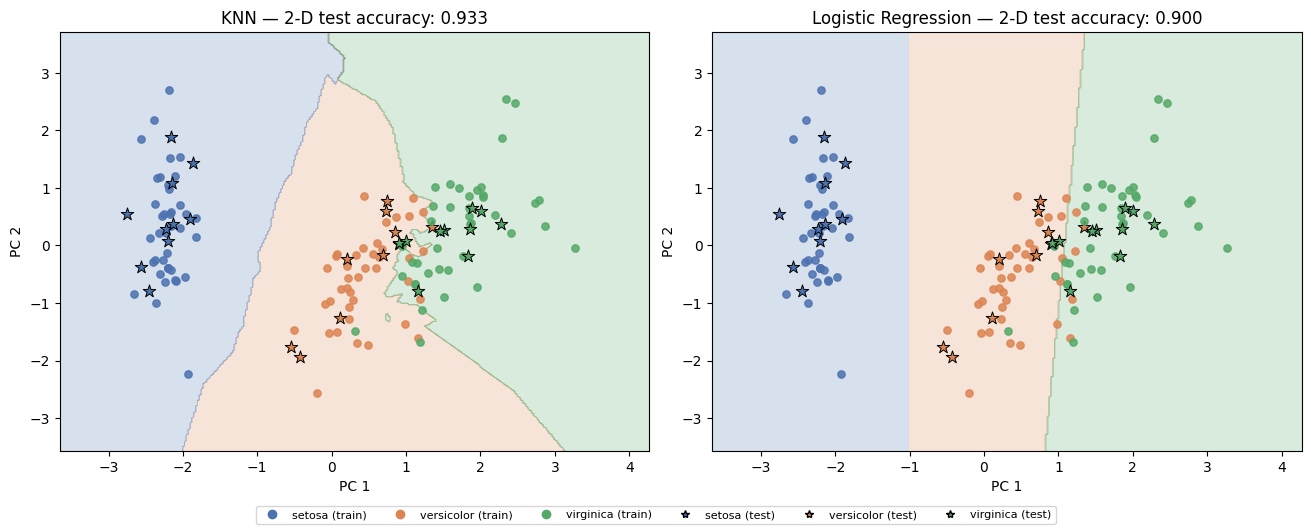

In [31]:
viz_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
])
X_train_2d = viz_pipe.fit_transform(X_train)
X_test_2d = viz_pipe.transform(X_test)
explained = viz_pipe.named_steps["pca"].explained_variance_ratio_.sum()
print(f"First two principal components explain {explained:.1%} of the variance")

knn_2d = KNeighborsClassifier(**{k.replace("model__", ""): v
                                 for k, v in knn_grid.best_params_.items()})
logreg_2d = LogisticRegression(**{k.replace("model__", ""): v
                                  for k, v in logreg_grid.best_params_.items()},
                               random_state=RANDOM_STATE)

pad = 1.0
x_min, x_max = X_train_2d[:, 0].min() - pad, X_train_2d[:, 0].max() + pad
y_min, y_max = X_train_2d[:, 1].min() - pad, X_train_2d[:, 1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 320), np.linspace(y_min, y_max, 320))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)
for ax, (name, model_2d) in zip(axes, {"KNN": knn_2d, "Logistic Regression": logreg_2d}.items()):
    model_2d.fit(X_train_2d, y_train)
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.22, cmap=ListedColormap(PALETTE))
    for idx, cls in enumerate(CLASS_NAMES):
        mask_train = (y_train.values == idx)
        mask_test = (y_test.values == idx)
        ax.scatter(X_train_2d[mask_train, 0], X_train_2d[mask_train, 1],
                   color=PALETTE[idx], s=28, alpha=0.85)
        ax.scatter(X_test_2d[mask_test, 0], X_test_2d[mask_test, 1],
                   color=PALETTE[idx], s=90, marker="*", edgecolor="black", linewidth=0.7)
    acc2d = accuracy_score(y_test, model_2d.predict(X_test_2d))
    ax.set_title(f"{name} — 2-D test accuracy: {acc2d:.3f}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")

legend_handles = (
    [Line2D([], [], marker="o", ls="", color=PALETTE[i],
            label=CLASS_NAMES[i].replace("Iris-", "") + " (train)") for i in range(3)]
    + [Line2D([], [], marker="*", ls="", color=PALETTE[i], markeredgecolor="black",
              label=CLASS_NAMES[i].replace("Iris-", "") + " (test)") for i in range(3)]
)
fig.legend(handles=legend_handles, loc="outside lower center", ncol=6, fontsize=8)
plt.show()

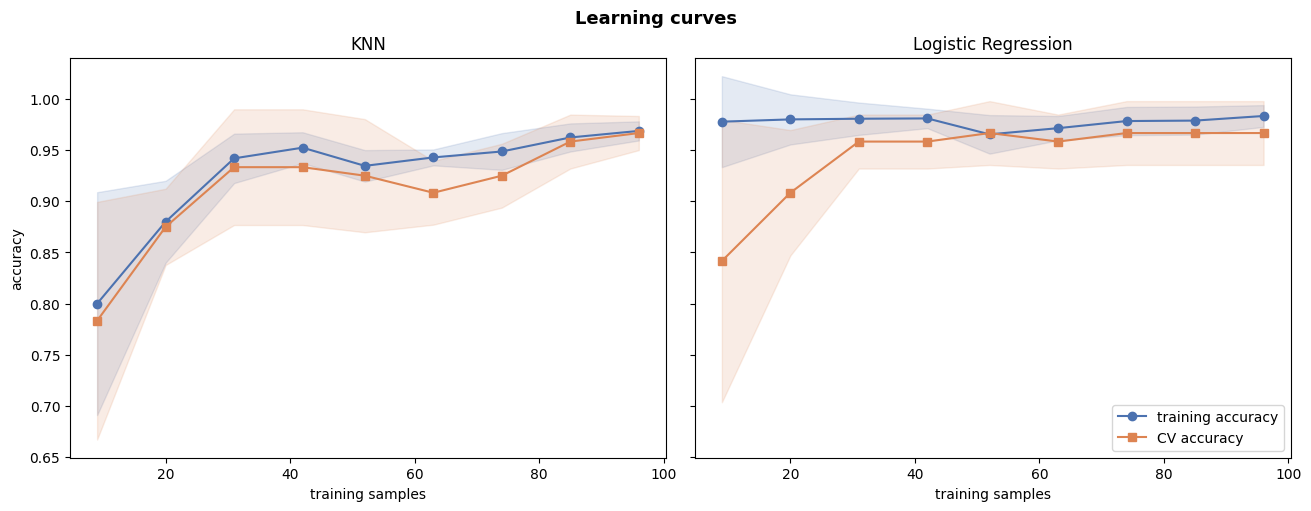

In [32]:
train_sizes = np.linspace(0.1, 1.0, 9)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, constrained_layout=True)
for ax, (name, model) in zip(axes, models.items()):
    sizes, tr, cvl = learning_curve(model, X_train, y_train, cv=CV,
                                    scoring="accuracy", train_sizes=train_sizes, n_jobs=-1)
    ax.plot(sizes, tr.mean(axis=1), "o-", color="#4C72B0", label="training accuracy")
    ax.fill_between(sizes, tr.mean(axis=1) - tr.std(axis=1),
                    tr.mean(axis=1) + tr.std(axis=1), color="#4C72B0", alpha=0.15)
    ax.plot(sizes, cvl.mean(axis=1), "s-", color="#DD8452", label="CV accuracy")
    ax.fill_between(sizes, cvl.mean(axis=1) - cvl.std(axis=1),
                    cvl.mean(axis=1) + cvl.std(axis=1), color="#DD8452", alpha=0.15)
    ax.set_title(name)
    ax.set_xlabel("training samples")
axes[0].set_ylabel("accuracy")
axes[1].legend(loc="lower right")
fig.suptitle("Learning curves", fontsize=13, fontweight="bold")
plt.show()

In [33]:
summary = pd.DataFrame({
    "Model": ["KNN (tuned)", "Logistic Regression (tuned)"],
    "Best CV accuracy (5-fold)": [best_cv["KNN"], best_cv["Logistic Regression"]],
    "Test accuracy": [accuracy_score(y_test, predictions["KNN"]),
                      accuracy_score(y_test, predictions["Logistic Regression"])],
    "Macro F1 (test)": [classification_report(y_test, predictions["KNN"], output_dict=True)["macro avg"]["f1-score"],
                        classification_report(y_test, predictions["Logistic Regression"],
                                              output_dict=True)["macro avg"]["f1-score"]],
    "Winning hyperparameters": [str(knn_grid.best_params_), str(logreg_grid.best_params_)],
})
summary.round(4)

,Model,Best CV accuracy (5-fold),Test accuracy,Macro F1 (test),Winning hyperparameters
0,KNN (tuned),0.9667,0.9333,0.9327,"{'model__n_neighbors': 3, 'model__p': 2, 'mode..."
1,Logistic Regression (tuned),0.9667,0.9667,0.9666,"{'model__C': 3.1622776601683795, 'model__max_i..."
